<a href="https://colab.research.google.com/github/NadiiaIvashchuk/DTA_2026/blob/main/ML/ml_practice_LR%26Cl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика: лінійна регресія та класифікація

Це тренувальний блокнот для закріплення базового циклу ML. Завдання **нескладні** й повторюють кроки з основного тьюторіалу — тільки тепер усе робиш **сам**.

**Дві задачі на двох нових наборах даних:**
- **Задача A (регресія):** передбачити **зарплату** працівника.
- **Задача B (класифікація):** передбачити, чи **складе студент іспит** (так/ні).

**Як працювати:**
1. Запусти комірку «Підготовка даних» нижче — вона все налаштує.
2. Іди по кроках. Там, де стоїть `# TODO`, — впиши свій код.
3. Підказки є під кожним кроком.

> 💡 Усі потрібні інструменти ти вже бачив: `train_test_split`, `LinearRegression`, `DecisionTreeClassifier`, `.fit()`, `.predict()`, метрики. Тримай той блокнот поруч як шпаргалку.

---

## 🔧 Підготовка даних (просто запусти)

In [70]:
# ▶️ Просто запусти цю комірку — вона готує дані. Міняти нічого не треба.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)

# ---------- Дані A: ЗАРПЛАТИ (для регресії) ----------
N = 800
experience = np.random.randint(0, 31, N)                      # стаж, років
age        = (22 + experience + np.random.randint(0, 12, N)).clip(22, 64)  # вік
education  = np.random.choice([12, 15, 16, 18, 20], N,        # років освіти
                              p=[.2, .15, .35, .2, .1])
english    = np.random.randint(1, 6, N)                       # рівень англ. 1..5

salary = (8000                       # базова ставка, грн
          + experience * 900         # за кожен рік стажу
          + education  * 600         # за рік освіти
          + english    * 1500        # за рівень англійської
          + np.random.normal(0, 3000, N)   # шум: усе інше
         ).clip(8000, None)

salary_df = pd.DataFrame({
    "experience": experience, "age": age,
    "education": education, "english": english,
    "salary": salary.round(0).astype(int),
})

# ---------- Дані B: СТУДЕНТИ (для класифікації) ----------
M = 800
study     = np.random.normal(12, 5, M).clip(0, 30)            # годин навчання/тиждень
attendance= np.random.normal(78, 15, M).clip(30, 100)        # відвідуваність, %
prev_score= np.random.normal(65, 18, M).clip(0, 100)         # бал за минулий іспит
sleep     = np.random.normal(7, 1.2, M).clip(4, 10)          # годин сну

score_logit = (0.12*study + 0.04*attendance + 0.05*prev_score
               + 0.3*sleep - 9 + np.random.normal(0, 1.2, M))
passed = (score_logit > 0).astype(int)                        # 1 = склав, 0 = ні

students_df = pd.DataFrame({
    "study": study.round(1), "attendance": attendance.round(0).astype(int),
    "prev_score": prev_score.round(0).astype(int), "sleep": sleep.round(1),
    "passed": passed,
})

print("✅ Дані готові.")
print("Зарплати:", salary_df.shape, "| Студенти:", students_df.shape)
print("Частка тих, хто склав іспит:", f"{students_df['passed'].mean():.0%}")

✅ Дані готові.
Зарплати: (800, 5) | Студенти: (800, 5)
Частка тих, хто склав іспит: 69%


---
# 🟦 Задача A. Регресія: передбачаємо зарплату

Дані у таблиці `salary_df`. Ознаки: `experience` (стаж), `age` (вік), `education` (років освіти), `english` (рівень англійської 1–5). Ціль: `salary` (зарплата, грн).

Мета — навчити модель передбачати зарплату і **пояснити**, що на неї впливає.

### Крок A1. Подивись на дані
Виведи перші рядки таблиці й описову статистику. Це звичка №1 перед будь-яким навчанням.

*Підказка:* `salary_df.head()` і `salary_df.describe()`.

In [71]:
# TODO: виведи перші рядки salary_df
salary_df.head()
# TODO: виведи describe()
salary_df.describe()


,experience,age,education,english,salary
count,800.000000,800.000000,800.000000,800.000000,800.000000
mean,15.418750,42.746250,15.856250,3.028750,36028.926250
std,9.328568,9.924338,2.408908,1.432826,9242.043432
min,0.000000,22.000000,12.000000,1.000000,12917.000000
25%,7.000000,35.000000,15.000000,2.000000,28550.750000
50%,16.000000,43.000000,16.000000,3.000000,36102.500000
75%,24.000000,51.000000,18.000000,4.000000,43545.500000
max,30.000000,62.000000,20.000000,5.000000,55947.000000


### Крок A2. Признач ознаки (X) і ціль (y), поділи на train / test
- `X` — усі стовпці, КРІМ `salary`.
- `y` — стовпець `salary`.
- Поділ: 20% у тест, `random_state=RANDOM_STATE`.

*Підказка:* `X = salary_df[["experience", "age", "education", "english"]]`,
`y = salary_df["salary"]`, далі `train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)`.

In [72]:
from sklearn.model_selection import train_test_split

# TODO: створи X та y
X = salary_df[['experience', 'age', 'education', 'english']]
y = salary_df['salary']

# TODO: поділи на X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 640 | Test: 160


### Крок A3. Навчи лінійну регресію
Згадай цикл: **створити → `.fit(X_train, y_train)`**.

*Підказка:* `from sklearn.linear_model import LinearRegression`, далі `model = LinearRegression()` і `model.fit(...)`.

In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

### Крок A4. Зроби передбачення й оціни якість
- Передбач на `X_test`.
- Порахуй **MAE** та **R²**.

*Підказка:* `y_pred = model.predict(X_test)`; `mean_absolute_error(y_test, y_pred)`;
`r2_score(y_test, y_pred)`.

In [74]:
from sklearn.metrics import mean_absolute_error, r2_score

# TODO: передбач y_pred
y_pred = model.predict(X_test)

# TODO: порахуй і виведи MAE та R²
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.1f} грн (у середньому помиляємось на стільки)")
print(f"R² = {r2:.3f} (модель пояснює {r2 * 100:.1f}% розкиду зарплат)")

MAE = 2545.3 грн (у середньому помиляємось на стільки)
R² = 0.881 (модель пояснює 88.1% розкиду зарплат)


### Крок A5. 🔑 Інтерпретуй коефіцієнти
Дістань коефіцієнти моделі й скажи словами, яка ознака найсильніше підвищує зарплату.

*Підказка:* `model.coef_` і `model.intercept_`. Зістав назви з `X.columns`.

In [75]:
# TODO: побудуй таблицю "ознака — коефіцієнт" і відсортуй
coefs = pd.DataFrame({
    'features': X.columns,
    'coef': model.coef_.round(2)
}).sort_values('coef', key=abs, ascending=False)

print(f"Базова зарплата: {model.intercept_:.2F}")
print("Найсильніше впливає на розмір зарплати рівень англійської, оскільки ця ознака вдвічі перевищує experience")
coefs

Базова зарплата: 6850.03
Найсильніше впливає на розмір зарплати рівень англійської, оскільки ця ознака вдвічі перевищує experience


,features,coef
3,english,1597.45
0,experience,872.48
2,education,609.59
1,age,31.15


✍️ **Запиши відповідь словами** (просто текстом у цій комірці, подвійний клік):
> Найсильніше впливає на розмір зарплати рівень англійської, оскільки ця ознака вдвічі перевищує experience. Коефіцієнти розраховані моделлю, релевантні логіці розрахунку запрлати, з незначними відхиленнями()

### Крок A6. Передбач зарплату для нового працівника
Створи одного працівника й передбач його зарплату: стаж 5, вік 30, освіта 16, англійська 4.

*Підказка:* зроби `pd.DataFrame([{...}])` з тими самими назвами стовпців і передай у `model.predict(...)`.

In [76]:
# TODO: створи new_employee і передбач зарплату
new_employee = pd.DataFrame([{
    'experience': 5,
    'age': 30,
    'education': 16,
    'english': 4
}])

print(f"Зарплата нового працівника становитиме: {model.predict(new_employee)[0]:.1f} грн. +- {mae:.1f} грн.")

new_employee



Зарплата нового працівника становитиме: 28290.2 грн. +- 2545.3 грн.


,experience,age,education,english
0,5,30,16,4


---
# 🟩 Задача B. Класифікація: чи складе студент іспит

Дані у таблиці `students_df`. Ознаки: `study` (годин навчання/тиждень), `attendance` (відвідуваність %), `prev_score` (бал за минулий іспит), `sleep` (годин сну). Ціль: `passed` (1 = склав, 0 = ні).

### Крок B1. Подивись на дані
Виведи перші рядки й перевір баланс класів: яка частка студентів склала іспит?

*Підказка:* `students_df.head()` і `students_df["passed"].mean()`.

In [77]:
# TODO: head() і частка тих, хто склав
students_df.head()
#students_df["passed"].mean().round(4)

,study,attendance,prev_score,sleep,passed
0,11.2,76,94,5.7,1
1,18.5,72,49,9.4,1
2,15.7,71,59,7.9,0
3,16.1,100,88,5.1,1
4,9.9,92,72,7.0,1


### Крок B2. X, y і поділ на train / test
- `X` — усе, крім `passed`. `y` — `passed`.
- Додай `stratify=y`, щоб пропорція класів збереглася.

*Підказка:* `train_test_split(Xs, ys, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)`.

In [78]:
# TODO: Xs, ys та поділ на Xs_train, Xs_test, ys_train, ys_test
from sklearn.model_selection import train_test_split

Xs = students_df[['study', 'attendance', 'prev_score', 'sleep']]
ys = students_df['passed']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=ys
)

print("Навчальна вибірка", X_train.shape[0], "студентів")
print("Тестова вибірка", X_test.shape[0], "студентів")

Навчальна вибірка 640 студентів
Тестова вибірка 160 студентів


### Крок B3. Навчи дерево рішень
Використай `DecisionTreeClassifier` з `max_depth=3` (щоб було просте й читабельне) і `random_state=RANDOM_STATE`.

*Підказка:* `from sklearn.tree import DecisionTreeClassifier`.

In [79]:
from sklearn.tree import DecisionTreeClassifier

# TODO: створи та навчи дерево
model_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

model_tree.fit(Xs_train, ys_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

### Крок B4. Передбач і оціни
- Передбач на `Xs_test`.
- Порахуй **accuracy** і побудуй **матрицю плутанини**.

*Підказка:* `accuracy_score(ys_test, ys_pred)` та `confusion_matrix(ys_test, ys_pred)`.

In [80]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TODO: передбач ys_pred, порахуй accuracy та матрицю плутанини

ys_pred = model_tree.predict(Xs_test)

acc = accuracy_score(ys_test, ys_pred)
print(f"Accuracy = {acc:.2%}\n")

cm = confusion_matrix(ys_test, ys_pred)
df_cm = pd.DataFrame(
    cm,
    index=['Не склав', 'Склав'],
    columns=['Передбачено не склав', 'Передбачено склав']
)
print(f"Mатриця плутанини:")
display(df_cm)

print("\nДетальний звіт:")
print(classification_report(ys_test, ys_pred, target_names=['не склав', 'склав']))


Accuracy = 75.62%

Mатриця плутанини:


,Передбачено не склав,Передбачено склав
Не склав,25,24
Склав,15,96



Детальний звіт:
              precision    recall  f1-score   support

    не склав       0.62      0.51      0.56        49
       склав       0.80      0.86      0.83       111

    accuracy                           0.76       160
   macro avg       0.71      0.69      0.70       160
weighted avg       0.75      0.76      0.75       160



### Крок B5. Що найбільше впливає на результат?
Виведи важливість ознак дерева й назви найважливішу.

*Підказка:* `tree.feature_importances_`, зістав із `Xs.columns`.

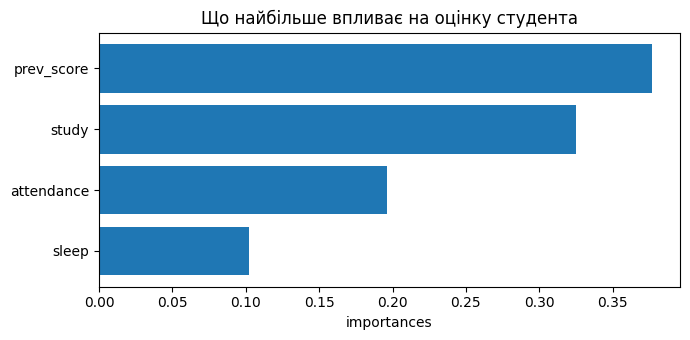

In [81]:
# TODO: таблиця "ознака — важливість", відсортована за спаданням
importances = pd.DataFrame({
    'features': Xs.columns,
    'importances': model_tree.feature_importances_.round(3)
}).sort_values('importances', ascending=True)

plt.figure(figsize=(7, 3.5))
plt.barh(importances['features'], importances['importances'])

plt.title("Що найбільше впливає на оцінку студента")
plt.xlabel('importances')
plt.tight_layout()
plt.show()


✍️ **Відповідь словами:**
> Найбільше на складання іспиту впливає ___.

### Крок B6. Передбач для нового студента
Студент: навчання 15 год, відвідуваність 85%, минулий бал 70, сон 7.5.
Виведи і рішення (`predict`), і **ймовірність** скласти (`predict_proba`).

*Підказка:* `predict_proba(...)[0, 1]` — це ймовірність класу «склав».

In [82]:
# TODO: створи new_student, виведи рішення та ймовірність
new_student = pd.DataFrame([{
    "study": 15,
    "attendance": 85,
    "prev_score": 70,
    "sleep": 7.5
}])

new_student
print(f"Ймовірнісь складання: {model_tree.predict_proba(new_student)[0, 1]:.2%}")
print(f"Рішення: {"Складе" if model_tree.predict(new_student)[0] else "НЕ складе"}")
print("\n------------------")
print(f"Вірогідність результату: {accuracy_score(ys_test, ys_pred):.2%}")


Ймовірнісь складання: 88.05%
Рішення: Складе

------------------
Вірогідність результату: 75.62%


---
# ⭐ Бонус (необов'язково, але корисно)

1. **Перевір на перенавчання.** Для дерева зі Задачі B порахуй accuracy окремо на `Xs_train` і на `Xs_test`. Великий розрив = зубріння. Потім спробуй `max_depth=10` — розрив зросте?
2. **Сильніша модель.** Навчи `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)` на тих самих даних і порівняй accuracy з деревом.
3. **Прибери ознаку.** У Задачі A прибери `experience` з `X`, перенавчи й подивись, як впаде R². Який висновок про важливість стажу?

## Бонус 1.

In [83]:
# accuracy окремо на Xs_train і на Xs_test
ys_train_pred = model_tree.predict(Xs_train)
ys_test_pred = model_tree.predict(Xs_test)

acc_train = accuracy_score(ys_train, ys_train_pred)
print(f"Train accuracy = {acc_train:.2%}")

acc_test = accuracy_score(ys_test, ys_test_pred)
print(f"Test accuracy = {acc_test:.2%}")

Train accuracy = 79.22%
Test accuracy = 75.62%


- Train accuracy = 79.22%
- Test accuracy = 75.62%  
Розрив між правильними відповідями і прогнозними для Train і Test невеликий

In [84]:
#Змінюємо створення моделі з втричі більшою глибиною і навчаємо її:
model_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=RANDOM_STATE
)

model_tree.fit(Xs_train, ys_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [85]:
# Повтопно рахуємо accuracy окремо на Xs_train і на Xs_test
ys_train_pred = model_tree.predict(Xs_train)
ys_test_pred = model_tree.predict(Xs_test)

acc_train = accuracy_score(ys_train, ys_train_pred)
print(f"Train accuracy = {acc_train:.2%}")

acc_test = accuracy_score(ys_test, ys_test_pred)
print(f"Test accuracy = {acc_test:.2%}")

Train accuracy = 97.03%
Test accuracy = 71.88%


Висновок:  
При збільшенні глибини з 3 до 10 точність на тренувальній вибірці збільшилась з 79.22% до 97.03%, але на тестовій вона зменшилась з 75.62%  до 71.88%. Отже модель перенавчилась, а по суті добре пристосувалась до навчальних даних, проте з тестовими точність впала

## Бонус 2.

In [86]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

model_forest.fit(Xs_train, ys_train)

ys_train_pred = model_forest.predict(Xs_train)
ys_test_pred = model_forest.predict(Xs_test)

acc_train = accuracy_score(ys_train, ys_train_pred)
print(f"Train accuracy = {acc_train:.2%}")

acc_test = accuracy_score(ys_test, ys_test_pred)
print(f"Test accuracy = {acc_test:.2%}")

Train accuracy = 100.00%
Test accuracy = 76.88%


Висновок:  
RandomForest показав кращий результат на тестовій виборці (76.88%) ніж DecisionTree (75.62%), він краще прогнозує данію

## Бонус 3.

In [88]:
# TODO: створи X та y
X = salary_df[['age', 'education', 'english']]
y = salary_df['salary']

# TODO: поділи на X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

model = LinearRegression()
model.fit(X_train, y_train)

# TODO: передбач y_pred
y_pred = model.predict(X_test)

# TODO: порахуй і виведи MAE та R²
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.1f} грн (у середньому помиляємось на стільки)")
print(f"R² = {r2:.3f} (модель пояснює {r2 * 100:.1f}% розкиду зарплат)")

MAE = 3572.3 грн (у середньому помиляємось на стільки)
R² = 0.767 (модель пояснює 76.7% розкиду зарплат)


Висновок:  
Видалення ознаки `experience` погіршило якісь моделі, тому ця ознака є важливим фактором для прогнозування запрлати

---
# 🧠 Питання на розуміння (без коду)

Дай собі відповідь словами (правильні — у блокноті з розв'язками):
1. Чому ми оцінюємо модель на `X_test`, а не на `X_train`?
- Ми оцінюємо модель на X_test, тому що це нові дані, яких модель не бачила під час навчання. Оцінка на X_train може бути завищеною, бо модель могла запам’ятати навчальні дані. Тестова вибірка показує, наскільки добре модель буде працювати на реальних даних  
  
2. Задача «передбачити кількість проданих квитків» — це регресія чи класифікація? А «спам / не спам»?  
- Передбачення кількості проданих квитків — це регресія, тому що потрібно передбачити числове значення.
Визначення «спам / не спам» — це класифікація, оскільки потрібно віднести об’єкт до одного з двох класів  
  
3. Що означає R² = 0.85 простими словами?
- Значення R² = 0.85 означає, що модель пояснює приблизно 85%. Тобто модель досить добре описує залежність і робить точні прогнози, а лише близько 15% розкиду залишаються непоясненими
  
4. Чому accuracy може бути оманливою, якщо лише 5% студентів провалюють іспит?
- Якщо лише 5% студентів провалюють іспит, то модель може передбачати для всіх «склав» і отримати accuracy 95%. Проте така модель взагалі не знаходить студентів, які не склали іспит. Тому в незбалансованих даних однієї лише accuracy недостатньо, і потрібно використовувати інші метрики, наприклад precision, recall або F1-score
  
5. Коефіцієнт `english = +1500`. Як прочитати це вголос для керівника?
- За інших однакових умов знання англійської мови пов’язане зі збільшенням зарплати приблизно на 1500 гривень. Тобто працівники, які знають англійську, у середньому заробляють приблизно на 1500 гривень більше.

> 🎯 Якщо впорався із задачами A і B без підглядання — ти впевнено володієш базовим циклом ML. Вітаю!